<a href="https://colab.research.google.com/github/melissa-04/melisayla-biyoinformatik/blob/main/notebooks/spatial/04_bolgeler_komsuluk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bölgeleri adlandırmak ve komşuluk analizi

Serinin son analiz defteri. İki iş var: 3.2'nin küme numaralarını anatomik bölge adlarına bağlamak, ve uzamsal verinin tek hücrede karşılığı olmayan sorusunu sormak — hangi bölgeler doku üzerinde birbirine komşu?

In [1]:
%pip install -q scanpy squidpy leidenalg igraph

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 8.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 82.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.5/280.5 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 84.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.8/188.8 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/

## 1. Hazırlık ve kümeleme

3.2'nin hattı aynen. Kümeleme resolution=0.5 ile; küme etiketlerini tam matrise (`v`) kopyalıyoruz, çünkü işaretçi genlerin çoğu daraltılmış matriste yok.

In [2]:
import warnings; warnings.filterwarnings('ignore')
import urllib.request
import scanpy as sc
import squidpy as sq
import numpy as np
import pandas as pd

urllib.request.urlretrieve('https://zenodo.org/records/22758390/files/spatial_ders.h5ad?download=1', 'spatial_ders.h5ad')
v = sc.read_h5ad('spatial_ders.h5ad')
v.layers['sayim'] = v.X.copy()
sc.pp.normalize_total(v, target_sum=1e4)
sc.pp.log1p(v)
sc.pp.highly_variable_genes(v, flavor='seurat', min_mean=0.0125, max_mean=3, min_disp=0.5)
v.raw = v

vv = v[:, v.var.highly_variable].copy()
sc.pp.scale(vv, max_value=10)
sc.tl.pca(vv, svd_solver='arpack', n_comps=50)
sc.pp.neighbors(vv, n_neighbors=15, n_pcs=10)
sc.tl.leiden(vv, resolution=0.5, key_added='leiden')
v.obs['leiden'] = vv.obs['leiden'].values
print('küme:', v.obs.leiden.nunique())

küme: 14


## 2. İşaretçi başına küme sıralaması

2.5'teki dotplot'un uzamsal karşılığı: her işaretçi için, o genin ortalama ifadesini küme küme hesaplayıp sıralıyoruz. Tepedeki küme, o işaretçinin adresidir. Kullandığımız işaretçiler ve karşılıkları:

- **Mbp, Mobp** — miyelin; ak madde
- **Hpca** — hipokampus
- **Ttr** — koroid pleksus
- **Slc17a7** — uyarıcı nöronların glutamat taşıyıcısı; korteks
- **Snap25, Nrgn** — genel nöronal sinyal; gri madde

`v.raw` tam matristir, bu yüzden işaretçileri oradan okuyoruz.

In [3]:
isaretciler = ['Mbp', 'Mobp', 'Hpca', 'Ttr', 'Slc17a7', 'Snap25', 'Nrgn']
for g in isaretciler:
    if g in v.raw.var_names:
        x = np.asarray(v.raw[:, g].X.todense()).ravel()
        s = pd.Series(x, index=v.obs_names).groupby(v.obs['leiden'].values).mean().sort_values(ascending=False)
        print(f'{g:9s}', {k: round(val, 2) for k, val in s.head(3).items()})

Mbp       {'3': 5.13, '5': 3.73, '1': 3.59}
Mobp      {'3': 3.82, '5': 2.44, '1': 2.24}
Hpca      {'12': 3.74, '13': 2.42, '4': 1.87}
Ttr       {'11': 4.83, '4': 2.4, '2': 2.25}
Slc17a7   {'12': 2.61, '0': 2.4, '6': 2.22}
Snap25    {'6': 3.38, '0': 3.27, '12': 3.09}
Nrgn      {'12': 3.72, '6': 3.65, '13': 3.62}


## 3. Adları işlemek

Yukarıdaki tabloya bakarak küme numaralarına ad veriyoruz. Yöntem 2.6'dakiyle aynı: bir eşleme sözlüğü kurup `map` ile yeni bir obs sütunu yazmak. Aşağıdaki liste benim koşumun sonucudur; kendi tablonuz farklı numaralar verebilir, o yüzden listeyi kendi çıktınıza göre düzenleyin. Emin olmadığınız kümelere numarasını koruyan bir ad (`Bölge 7` gibi) vermek meşrudur — 2.5'teki kural burada da geçerli, uydurulmuş kesinlik yanlış ad demektir.

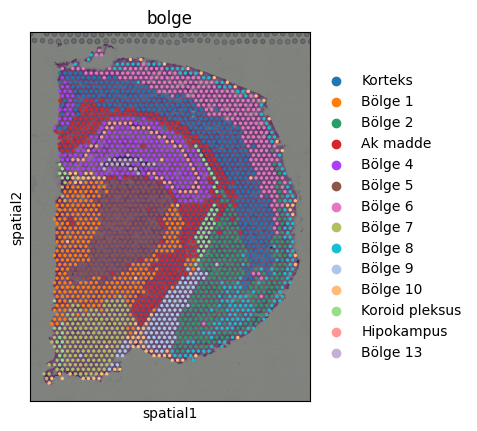

In [4]:
# kendi çıktınıza göre düzenleyin
adlar = {'3': 'Ak madde', '12': 'Hipokampus', '11': 'Koroid pleksus', '0': 'Korteks'}
v.obs['bolge'] = v.obs['leiden'].map(lambda k: adlar.get(k, f'Bölge {k}')).astype('category')

sc.pl.spatial(v, color='bolge')

## 4. Komşuluk zenginleştirmesi

Bu serinin son yeni aracı ve tek hücrede karşılığı olmayan analiz. Soru şu: iki küme doku üzerinde beklenenden daha sık mı yan yana duruyor?

`sq.gr.nhood_enrichment(v, cluster_key='leiden')` şunu yapar: uzamsal komşuluk grafiğindeki her komşu spot çiftinin hangi kümelere ait olduğunu sayar, sonra küme etiketlerini rastgele karıştırıp aynı sayımı binlerce kez tekrarlar ve gerçek sayının rastgele dağılımdan kaç standart sapma uzakta olduğunu verir. Sonuç bir z-skoru matrisidir: yüksek pozitif değer "bu iki küme birbirine komşu olmayı seviyor", negatif değer "birbirinden kaçınıyor" demektir.

Matrisin köşegeni her kümenin kendi kendine komşuluğudur ve doğal olarak çok yüksektir — bir kümenin spotları zaten bir arada oturur. Bilgi köşegenin dışındadır.

INFO     Creating graph using `None` transform and `1` libraries.                                                  


  0%|          | 0/1000 [00:00<?, ?/s]

z-skoru matrisi: (14, 14)
aralık: -18 .. 80
köşegen medyanı: 61
en güçlü komşuluk: küme 4 ile 12  (z=30.5)
en güçlü kaçınma:  küme 0 ile 1  (z=-18.1)


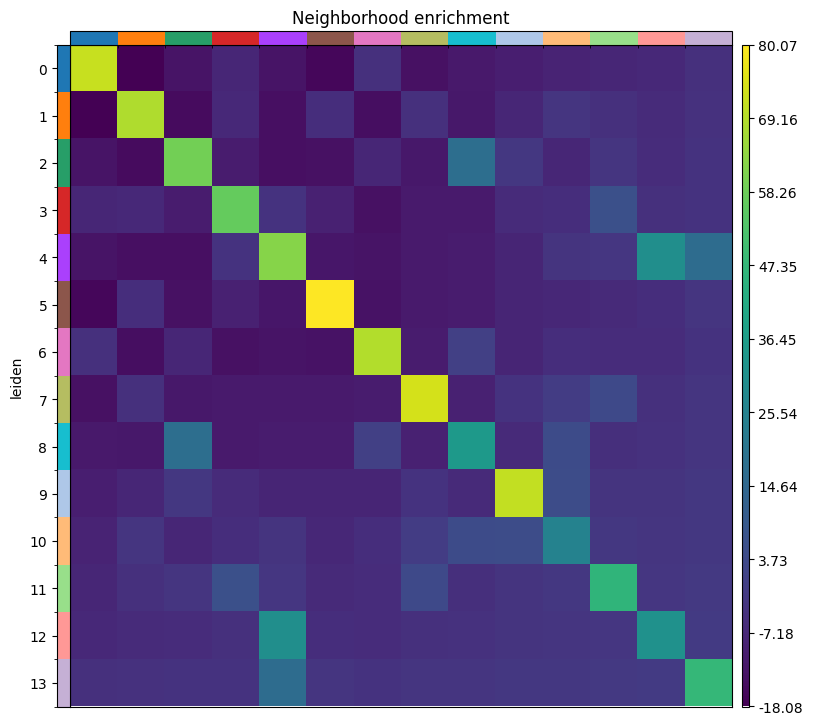

In [5]:
sq.gr.spatial_neighbors(v)
sq.gr.nhood_enrichment(v, cluster_key='leiden')

z = v.uns['leiden_nhood_enrichment']['zscore']
print('z-skoru matrisi:', z.shape)
print('aralık: %.0f .. %.0f' % (np.nanmin(z), np.nanmax(z)))
print('köşegen medyanı: %.0f' % np.median(np.diag(z)))

zc = z.copy()
np.fill_diagonal(zc, np.nan)
i, j = np.unravel_index(np.nanargmax(zc), zc.shape)
p, q = np.unravel_index(np.nanargmin(zc), zc.shape)
print(f'en güçlü komşuluk: küme {i} ile {j}  (z={zc[i, j]:.1f})')
print(f'en güçlü kaçınma:  küme {p} ile {q}  (z={zc[p, q]:.1f})')

sq.pl.nhood_enrichment(v, cluster_key='leiden', figsize=(7, 7))

## Kendin dene

Üç görev. Birincisi: işaretçi tablonuzdan en az dört kümeyi anatomik bölgeyle eşleştirin ve adlandırılmış haritanızı çizin; hangi kümeye hangi işaretçiye dayanarak ad verdiğinizi yazın. İkincisi: komşuluk matrisinizde en yüksek z-skorlu küme çiftini bulun, ikisinin adlarını yazın ve tek cümleyle söyleyin — bu komşuluk beynin bilinen anatomisiyle uyuşuyor mu? Üçüncüsü, serinin kapanış sorusu: bu analiz tek hücre verisinde neden yapılamazdı? Tek cümle.